In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('C:\\Users\\chira\\OneDrive\\Desktop\\Predicting Irrigation Need\\train.csv')
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
df.shape

(630000, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

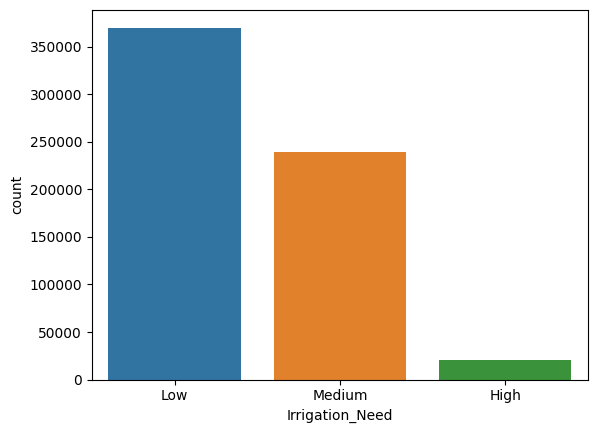

Irrigation_Need
Low       0.587170
Medium    0.379483
High      0.033348
Name: proportion, dtype: float64


In [5]:
sns.countplot(data=df, x="Irrigation_Need")
plt.show()

print(df["Irrigation_Need"].value_counts(normalize=True))

In [6]:
#missing values
df.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.00,157499.7500,314999.50,472499.25,629999.00
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00


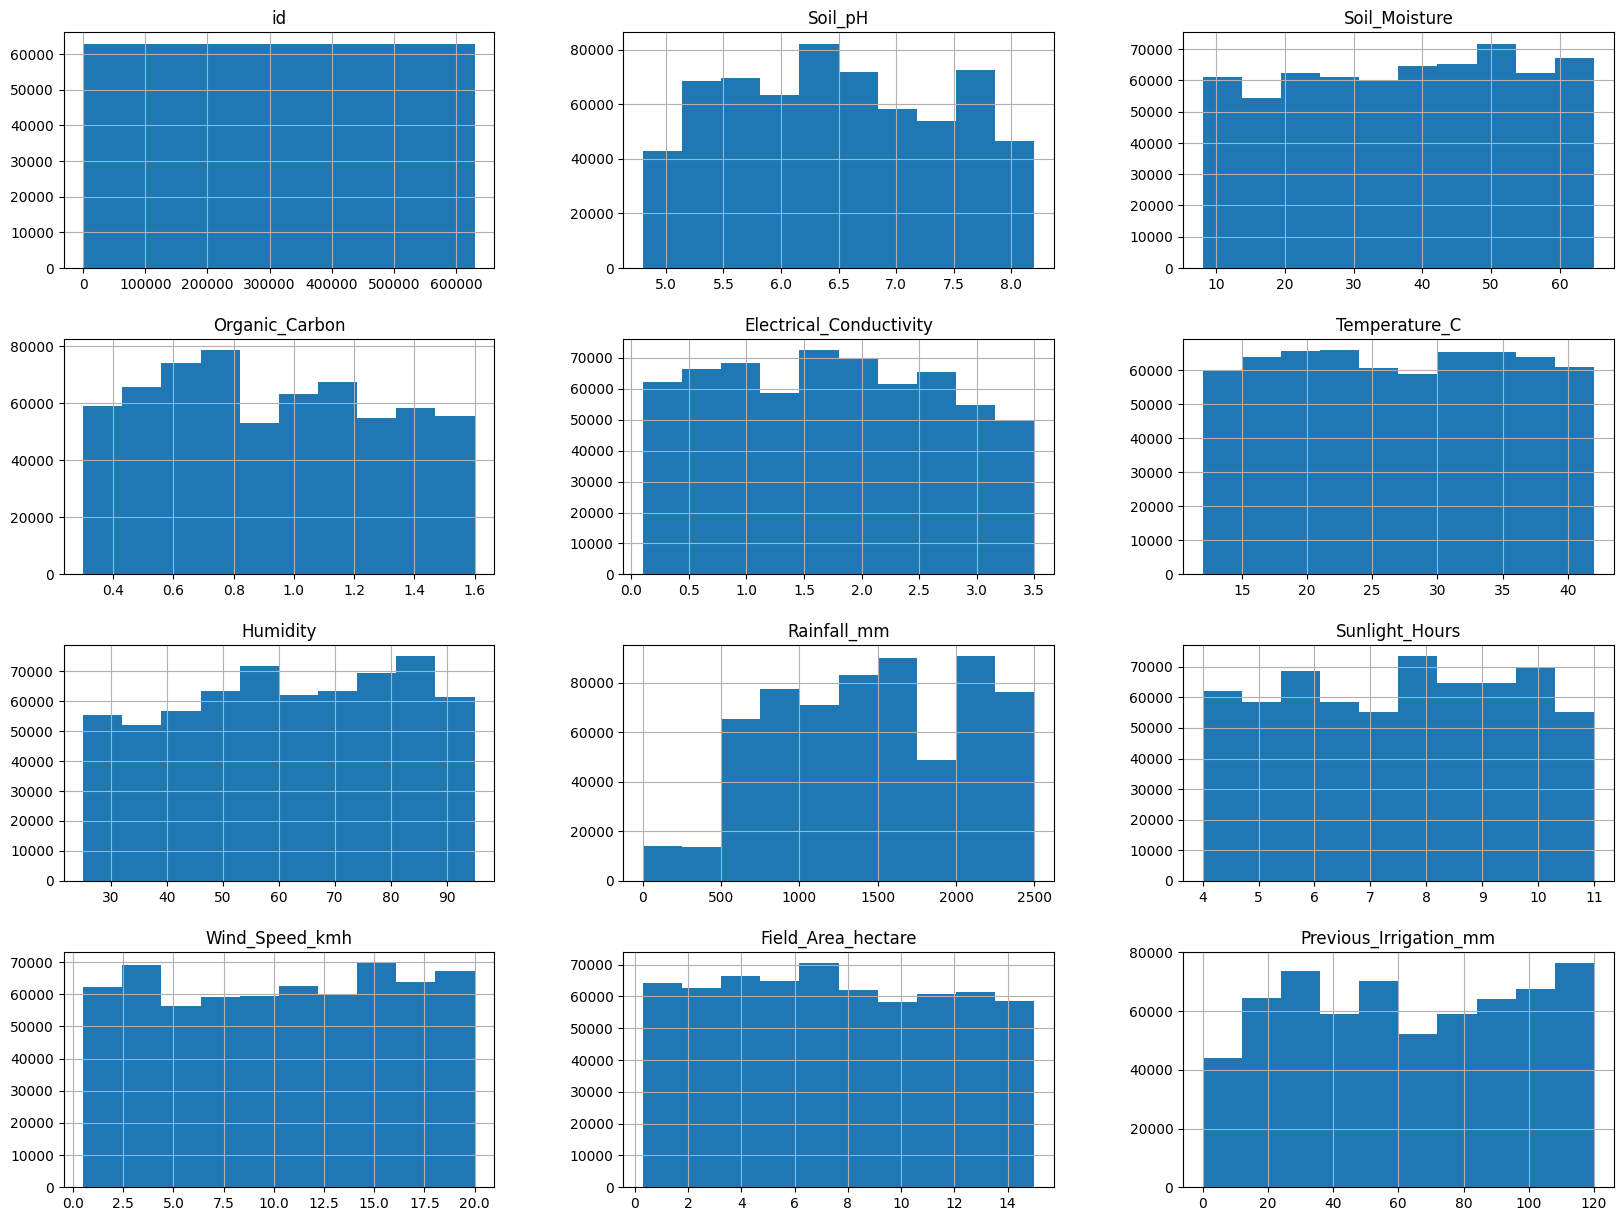

In [8]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

df[num_cols].hist(figsize=(20,15))
plt.show()

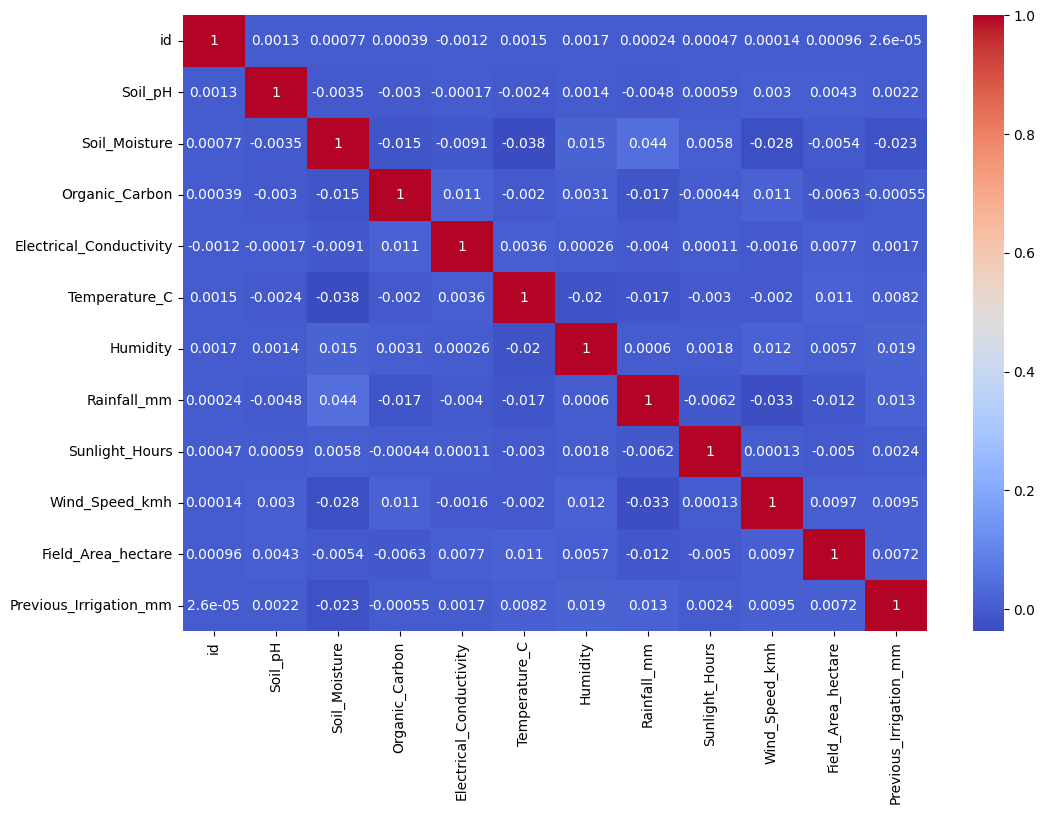

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

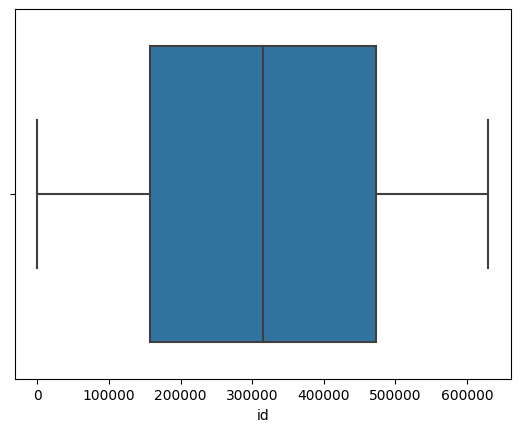

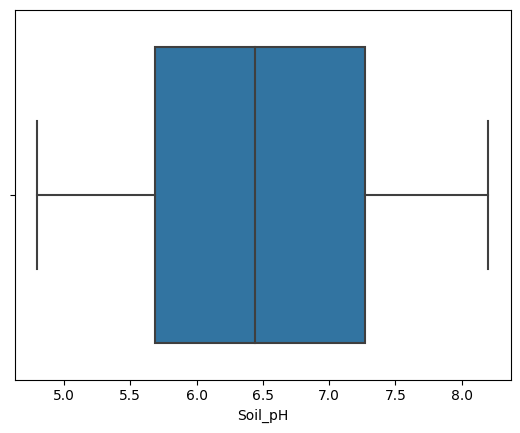

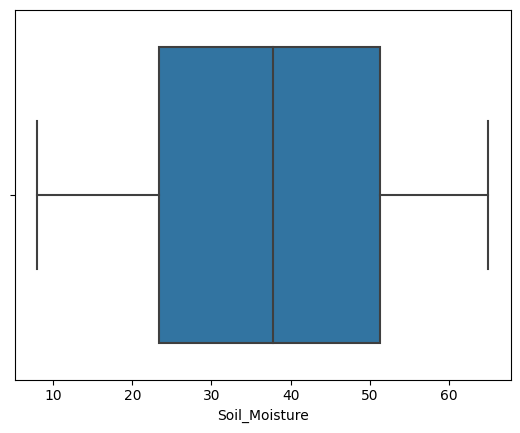

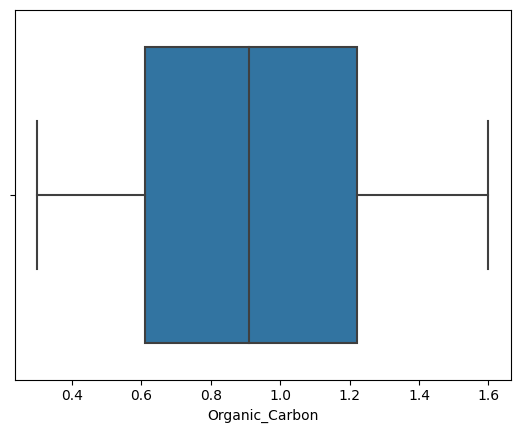

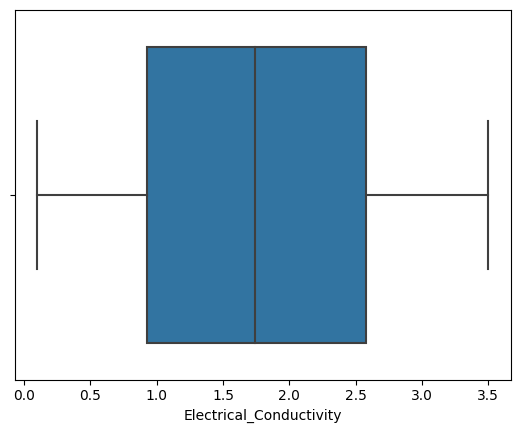

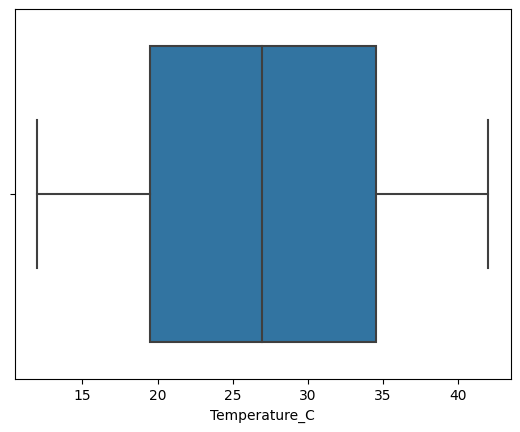

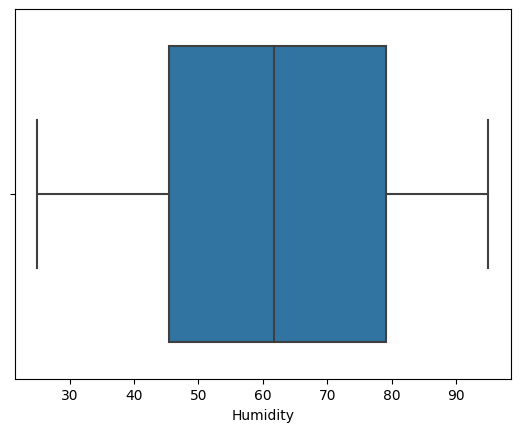

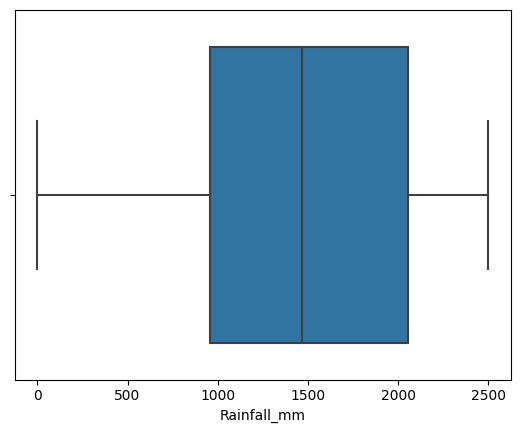

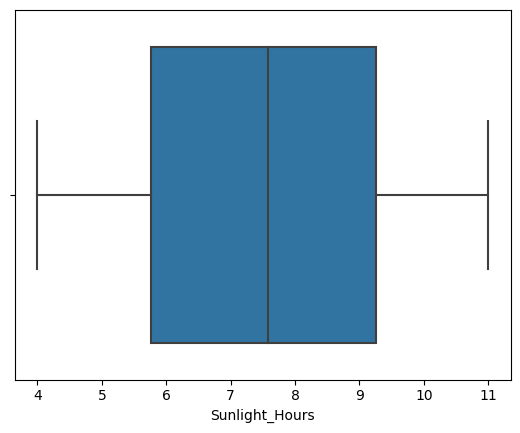

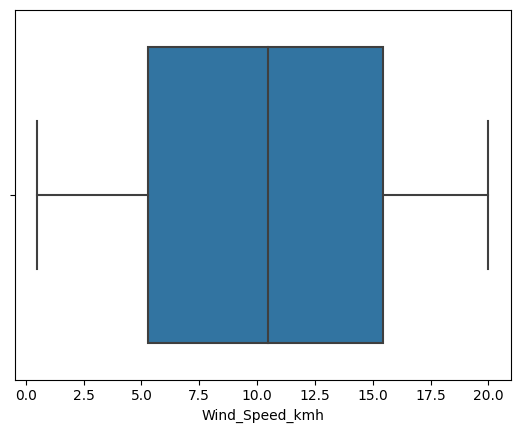

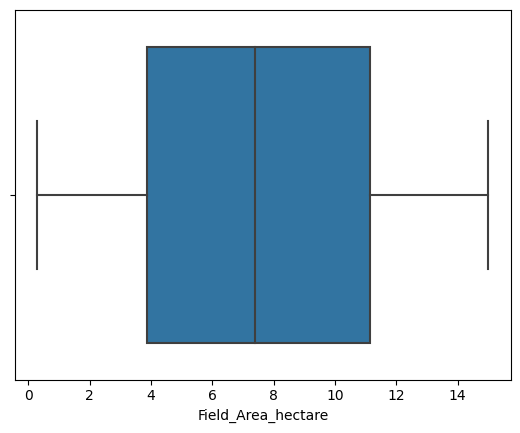

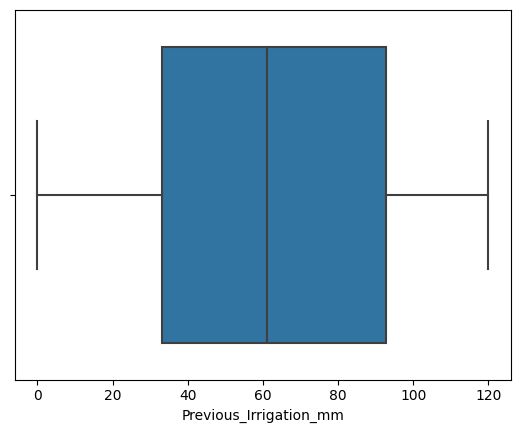

In [10]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()

In [11]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(df[col].value_counts())

Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64
Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64
Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: count, dtype: int64
Season
Kharif    216561
Rabi      208033
Zaid      205406
Name: count, dtype: int64
Irrigation_Type
Canal        161901
Sprinkler    161400
Rainfed      155607
Drip         151092
Name: count, dtype: int64
Water_Source
Reservoir      162994
River          159819
Groundwater    154155
Rainwater      153032
Name: count, dtype: int64
Mulching_Used
No     316453
Yes    313547
Name: count, dtype: int64
Region
South      134809
West       131189
East       126163
Central    123712
North      114127
Name: count, dtype: int64
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

<AxesSubplot: xlabel='Irrigation_Need', ylabel='Soil_Moisture'>

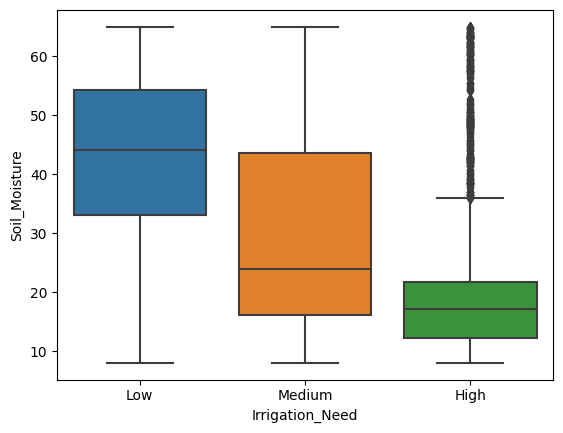

In [12]:
sns.boxplot(
    x="Irrigation_Need",
    y="Soil_Moisture",
    data=df
)

In [13]:
#feature engineering(EDA)

df["Moisture_Deficit"] = (
    100 - df["Soil_Moisture"]
)

In [14]:
df["Water_Availability"] = (
    df["Rainfall_mm"] +
    df["Previous_Irrigation_mm"]
)

In [15]:
df["Evaporation"] = (
    df["Temperature_C"]
    *
    df["Sunlight_Hours"]
    /
    (df["Humidity"] + 1)
)

In [16]:
df["Heat_Stress"] = (
    df["Temperature_C"]
    *
    df["Wind_Speed_kmh"]
)

In [17]:
df["Water_per_Area"] = (
    df["Previous_Irrigation_mm"]
    /
    df["Field_Area_hectare"]
)

In [18]:
df["Moisture_Rain"] = (
    df["Soil_Moisture"]
    *
    df["Rainfall_mm"]
)

In [19]:
df["pH_Category"] = pd.cut(
    df["Soil_pH"],
    bins=[0,6.5,7.5,14],
    labels=[
        "Acidic",
        "Neutral",
        "Alkaline"
    ]
)

In [20]:
#REMOVE COLUMNS WHICH ARE USED IN EDA
col=['Soil_Moisture','Rainfall_mm','Previous_Irrigation_mm','Temperature_C','Sunlight_Hours','Humidity','Wind_Speed_kmh','Field_Area_hectare','Soil_pH']

df = df.drop(columns=col)

In [21]:
# apply catboost algorithm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier, Pool

# Use CatBoost's native categorical handling instead of one-hot encoding.
X = df.drop(columns=["Irrigation_Need", "id"])
y = df["Irrigation_Need"]

cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_features:
    X[col] = X[col].astype(str)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    early_stopping_rounds=100,
    verbose=100
)

model = cat_model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

valid_pred = model.predict(valid_pool).ravel()
print("Validation Accuracy:", accuracy_score(y_valid, valid_pred))
print(classification_report(y_valid, valid_pred))
print(confusion_matrix(y_valid, valid_pred))

0:	learn: 0.9231944	test: 0.9232381	best: 0.9232381 (0)	total: 1s	remaining: 16m 43s
100:	learn: 0.9367083	test: 0.9370079	best: 0.9370079 (100)	total: 1m 11s	remaining: 10m 35s
200:	learn: 0.9385972	test: 0.9389048	best: 0.9389048 (200)	total: 2m 20s	remaining: 9m 18s
300:	learn: 0.9394107	test: 0.9395397	best: 0.9395952 (283)	total: 3m 29s	remaining: 8m 5s
400:	learn: 0.9400873	test: 0.9400556	best: 0.9401349 (390)	total: 4m 38s	remaining: 6m 55s
500:	learn: 0.9404504	test: 0.9401508	best: 0.9402619 (475)	total: 5m 47s	remaining: 5m 45s
600:	learn: 0.9409187	test: 0.9405397	best: 0.9405476 (599)	total: 6m 55s	remaining: 4m 36s
700:	learn: 0.9412163	test: 0.9408571	best: 0.9408651 (698)	total: 8m 4s	remaining: 3m 26s
800:	learn: 0.9415853	test: 0.9409127	best: 0.9409603 (792)	total: 9m 11s	remaining: 2m 17s
900:	learn: 0.9419028	test: 0.9411111	best: 0.9411984 (882)	total: 10m 20s	remaining: 1m 8s
999:	learn: 0.9421845	test: 0.9412778	best: 0.9413254 (956)	total: 11m 28s	remaining: 0u

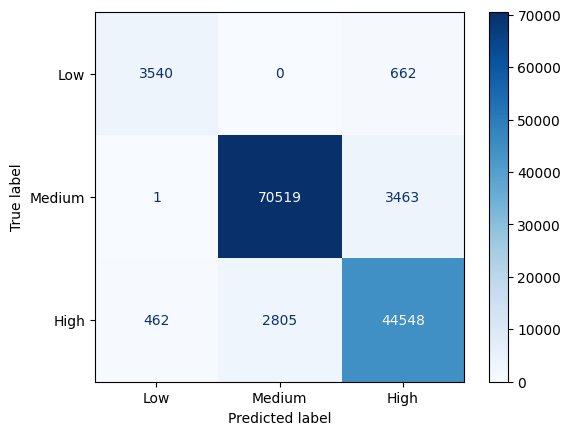

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_valid, valid_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=['Low', 'Medium', 'High']
)

disp.plot(cmap='Blues')
plt.show()

In [23]:
# Train final CatBoost model on the full training data
full_train_pool = Pool(X, y, cat_features=cat_features)

final_cat_model = CatBoostClassifier(
    iterations=cat_model.get_best_iteration() or 1000,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

final_cat_model.fit(full_train_pool)


0:	learn: 0.9232889	total: 943ms	remaining: 15m
100:	learn: 0.9371730	total: 1m 19s	remaining: 11m 12s
200:	learn: 0.9389302	total: 2m 36s	remaining: 9m 49s
300:	learn: 0.9398952	total: 3m 54s	remaining: 8m 29s
400:	learn: 0.9404016	total: 5m 13s	remaining: 7m 14s
500:	learn: 0.9408635	total: 6m 35s	remaining: 5m 59s
600:	learn: 0.9412556	total: 7m 54s	remaining: 4m 40s
700:	learn: 0.9416302	total: 9m 14s	remaining: 3m 21s
800:	learn: 0.9420302	total: 10m 33s	remaining: 2m 2s
900:	learn: 0.9423032	total: 11m 50s	remaining: 43.4s
955:	learn: 0.9423730	total: 12m 33s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=956, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [24]:
print(X.columns)
test_df = pd.read_csv(r"C:\Users\chira\OneDrive\Desktop\Predicting Irrigation Need\test.csv")

test_df.info()

Index(['Soil_Type', 'Organic_Carbon', 'Electrical_Conductivity', 'Crop_Type',
       'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source',
       'Mulching_Used', 'Region', 'Moisture_Deficit', 'Water_Availability',
       'Evaporation', 'Heat_Stress', 'Water_per_Area', 'Moisture_Rain',
       'pH_Category'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  flo

In [35]:
import pandas as pd
from catboost import Pool

test_df = pd.read_csv(r"C:\Users\chira\OneDrive\Desktop\Predicting Irrigation Need\test.csv")
sample_submission = pd.read_csv(r"C:\Users\chira\OneDrive\Desktop\Predicting Irrigation Need\sample_submission.csv")

def add_features(df):
    df = df.copy()

    df["Moisture_Deficit"] = 100 - df["Soil_Moisture"]

    df["Water_Availability"] = (
        df["Rainfall_mm"] + df["Previous_Irrigation_mm"]
    )

    df["Evaporation"] = (
        df["Temperature_C"]
        * df["Sunlight_Hours"]
        /
        (df["Humidity"] + 1)
    )

    df["Heat_Stress"] = (
        df["Temperature_C"]
        * df["Wind_Speed_kmh"]
    )

    df["Water_per_Area"] = (
        df["Previous_Irrigation_mm"]
        /
        df["Field_Area_hectare"]
    )

    df["Moisture_Rain"] = (
        df["Soil_Moisture"]
        * df["Rainfall_mm"]
    )

    df["pH_Category"] = pd.cut(
        df["Soil_pH"],
        bins=[0, 6.5, 7.5, 14],
        labels=["Acidic", "Neutral", "Alkaline"]
    )

    drop_cols = [
        "Soil_Moisture",
        "Rainfall_mm",
        "Previous_Irrigation_mm",
        "Temperature_C",
        "Sunlight_Hours",
        "Humidity",
        "Wind_Speed_kmh",
        "Field_Area_hectare",
        "Soil_pH"
    ]

    return df.drop(columns=drop_cols)


test_processed = add_features(test_df)

X_test = test_processed.drop(columns=["id"])

for col in cat_features:
    X_test[col] = X_test[col].astype(str)

test_pool = Pool(
    X_test,
    cat_features=cat_features
)

predictions = final_cat_model.predict(test_pool).ravel()

submission = sample_submission.copy()
submission["Irrigation_Need"] = predictions

submission.to_csv(
    r"C:\Users\chira\OneDrive\Desktop\Predicting Irrigation Need\submission.csv",
    index=False
)

submission.head()

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


In [36]:
#save the model
final_cat_model.save_model(r"C:\Users\chira\OneDrive\Desktop\Predicting Irrigation Need\final_model.cbm")